# Algoritmos - Actividad Guiada 3

* **Nombre:** Marcos Antonio Lévano Huamaccto
* **Link a Google Colab:** [Acceder al Cuaderno Interactivo](https://colab.research.google.com/drive/1TNTNsq4GkmNuQHnOABb1M11gTR8JuYLw?usp=sharing)
* **Repositorio GitHub:** [Ver Código Fuente](https://github.com/marlev88/AlgoritmosOptimizacion)

# Ejecuciones

Carga de librerias

In [1]:
#!pip install tsplib95
import tsplib95
import random
from math import e
import math
import copy
import urllib.request

In [ ]:
#!pip install requests    #Hacer llamadas http a paginas de la red
#!pip install tsplib95    #Modulo para las instancias del problema del TSP

## Carga de los datos del problema

In [2]:
# Descargamos el fichero de datos (Matriz de distancias)
file = "swiss42.tsp" ;
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )


('swiss42.tsp', <http.client.HTTPMessage at 0x2048944da90>)

In [3]:
problema = tsplib95.load(file)
nodos = list(problema.get_nodes())
aristas = list(problema.get_edges())

print(problema) # Descripción estándar
print(nodos) # Nodos 0, 1, 2 ... 42
print(aristas) # Ver https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

NAME: swiss42
COMMENT: 42 Staedte Schweiz (Fricker)
TYPE: TSP
DIMENSION: 42
EDGE_WEIGHT_TYPE: EXPLICIT
EDGE_WEIGHT_FORMAT: FULL_MATRIX
EDGE_WEIGHT_SECTION:
0 15 30 23 32 55 33 37 92 114 92 110 96 90 74 76 82 67 72 78 82 159 122 131 206 112 57 28 43 70 65 66 37 103 84 125 129 72 126 141 183 124
15 0 34 23 27 40 19 32 93 117 88 100 87 75 63 67 71 69 62 63 96 164 132 131 212 106 44 33 51 77 75 72 52 118 99 132 132 67 139 148 186 122
30 34 0 11 18 57 36 65 62 84 64 89 76 93 95 100 104 98 57 88 99 130 100 101 179 86 51 4 18 43 45 95 45 115 93 152 159 100 112 114 153 94
23 23 11 0 11 48 26 54 70 94 69 89 75 84 84 89 92 89 54 78 99 141 111 109 190 89 44 11 29 54 56 89 47 118 96 147 151 90 122 126 163 101
32 27 18 11 0 40 20 58 67 92 61 78 65 76 83 89 91 95 43 72 110 141 116 105 190 81 34 19 35 57 63 97 58 129 107 156 158 92 129 127 161 95
55 40 57 48 40 0 23 55 96 123 78 75 62 36 56 66 63 95 37 34 137 174 156 129 224 90 15 59 75 96 103 105 91 158 139 164 156 78 169 163 191 115
33 19 36 26 20 

23


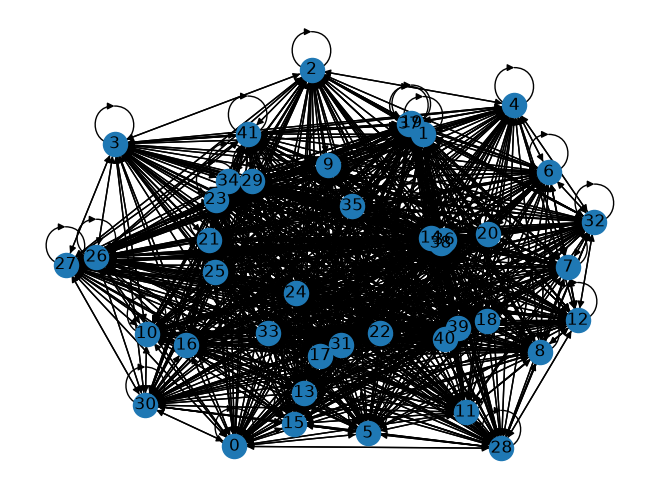

In [4]:
# Probamos algunas funciones del objeto problema, que ya nos vienen dadas
# Distancia entre nodos (ciudades)
distancia = problema.get_weight(3, 0)
print(distancia)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
#dir(problema)

import networkx as nx
import matplotlib.pyplot as plt
nx.draw(problema.get_graph(), with_labels=True, arrows=True)
plt.show()

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, metric="precomputed", init="random", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

### Funciones básicas

In [9]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion


# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)


# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)


solucion = crear_solucion(nodos)
print(solucion)
print(distancia_total(solucion, problema))

[0, 10, 40, 8, 37, 13, 19, 25, 39, 41, 32, 12, 22, 2, 14, 21, 24, 9, 16, 15, 28, 36, 17, 26, 23, 34, 6, 35, 31, 20, 11, 3, 27, 4, 30, 5, 18, 33, 29, 38, 7, 1]
4256


## Búsqueda aleatoria - TSP

- El algoritmo inicializa soluciones al azar y se queda con la mejor que encuentre
- Se realizan N iteraciones y nos quedamos con la mejor
- Todo es azar, sin que garanticemos solución óptima


Solución: [0, 36, 30, 24, 21, 41, 6, 13, 8, 3, 15, 37, 1, 12, 31, 17, 35, 32, 27, 33, 5, 19, 4, 18, 29, 25, 9, 38, 22, 11, 39, 40, 28, 2, 16, 34, 20, 10, 23, 26, 14, 7]
Distancia: 3655


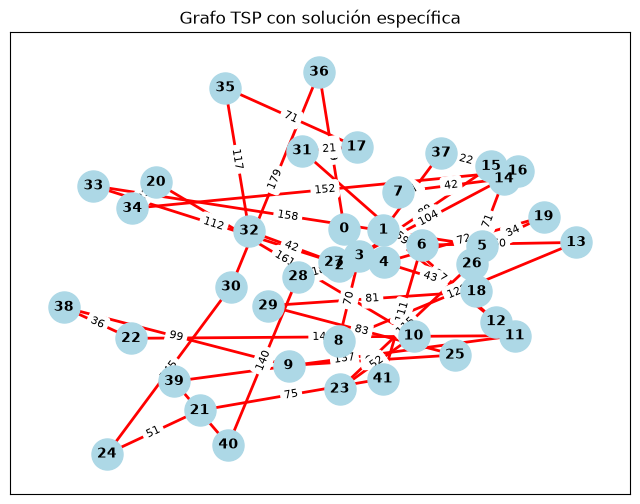

In [17]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problema, iteraciones):
    # Obtenemos listado de nodos del problema
    nodos = list(problema.get_nodes())

    mejor_solucion = []
    mejor_distancia_total = float("inf")

    for i in range(iteraciones):
        # Generamos solución aleatoria
        solucion = crear_solucion(nodos)
        # Calculamos distancia total de la solución
        distancia = distancia_total(solucion, problema)
        if (distancia < mejor_distancia_total):
            mejor_solucion = solucion
            mejor_distancia_total = distancia

    return mejor_solucion, mejor_distancia_total

iteraciones = 5000
mejor_solucion, mejor_distancia_total = busqueda_aleatoria(problema, iteraciones)

print(f"Solución: {mejor_solucion}")
print(f"Distancia: {mejor_distancia_total}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Búsqueda local - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones
- Se realizan N iteraciones y nos quedamos con la mejor

In [33]:
# Función que a partir de una solución genera la vecina óptima (es decir, la mejor vecina de todas las que existen)
def genera_mejor_vecina(solucion):
    # Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones en el bucle
    # Se puede modificar para aplicar otros generadores distintos que 2-opt como inversión, barajado...
    #print(solucion)

    mejor_solucion = []
    mejor_distancia = float("inf")

    #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for i in range(1,len(solucion)-1):
        for j in range(i+1, len(solucion)):
            # Generamos nueva solución vecina (0, 1, 2, 3, i, ..., j, ..., 41) -> (0, 1, 2, 3, j, ..., i, ..., 41)
            vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

            # Se evalua la nueva solución
            distancia_vecina = distancia_total(vecina, problema)

            # Si es la mejor solución, la almacenamos
            if (distancia_vecina <= mejor_distancia):
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Devolvemos mejor vecina
    return mejor_solucion


solucion = crear_solucion(nodos)
print(f"Distancia Solucion Incial: {distancia_total(solucion, problema)}")

nueva_solucion = genera_mejor_vecina(solucion)
print(f"Distancia Mejor Solucion Local: {distancia_total(nueva_solucion, problema)}")

Distancia Solucion Incial: 4491
Distancia Mejor Solucion Local: 4035


En la iteracion 43 la mejor solución encontrada es: [0, 1, 7, 31, 20, 33, 34, 38, 22, 8, 25, 10, 32, 35, 36, 17, 37, 15, 16, 14, 19, 13, 5, 6, 26, 18, 12, 11, 41, 23, 9, 40, 24, 21, 39, 29, 30, 28, 27, 2, 4, 3]
Distancia: 1580


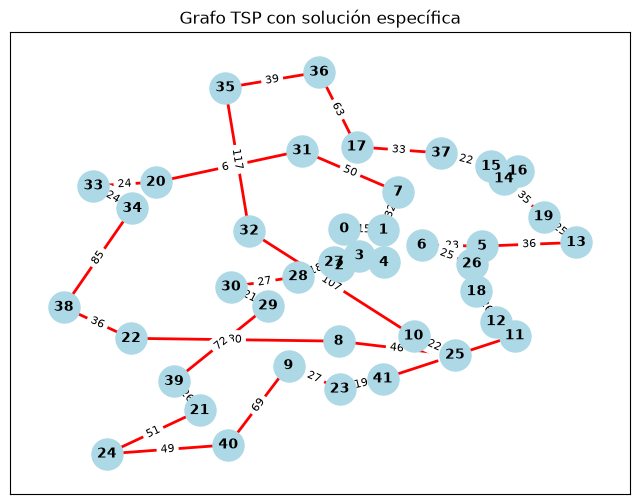

In [37]:
# En este caso, la búsqueda se ejecuta sin criterio de parada, se para cuando no es posible mejorar.
# Aquí iremos recorriendo las mejores vecinas para ir construyendo trayectoria
def busqueda_local(problema):
    mejor_solucion = []

    # Generar una solucion inicial de referencia(aleatoria)
    solucion_referencia = crear_solucion(nodos)
    mejor_distancia = distancia_total(solucion_referencia, problema)

    # Contador de iteraciones (por tener referencia)
    iteracion = 0

    while(1):
        iteracion += 1
        #print('#',iteracion)

        # Obtenemos la mejor vecina
        vecina = genera_mejor_vecina(solucion_referencia)

        # Evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
        distancia_vecina = distancia_total(vecina, problema)

        # Si mejoramos hay que seguir
        if (distancia_vecina < mejor_distancia):
            #mejor_solucion = copy.deepcopy(vecina)   # Con copia profunda. Las copias en python son por referencia
            mejor_solucion = vecina                   # Guarda la mejor solución encontrada
            mejor_distancia = distancia_vecina

        # Si no mejoramos, retornamos ya que hemos llegado a un minimo local (según nuestro operador de vecindad 2-opt)
        else:
            #print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
            #print(f"Distancia: {mejor_distancia}")
            return mejor_solucion, mejor_distancia, iteracion

        solucion_referencia = vecina


mejor_solucion, mejor_distancia, iteracion = busqueda_local(problema)
print(f"En la iteracion {iteracion} la mejor solución encontrada es: {mejor_solucion}")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Recocido simulado (Simulated Annealing) - TSP
- El algoritmo se va quedando con vecinos (operadores de vecindad) para intentar converger a mejores soluciones, aunque ahora a veces puedo elegir vecinos peores
- Al principio, elijo más veces vecinos peores (diversifico) y luego elijo menos veces esos vecinos peores (intensifico)
- Se realizan N iteraciones o bajamos temperatura al máximo

### Funciones auxiliares

In [55]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

# Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
def genera_vecina_aleatorio(solucion):

  # Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample(range(1,len(solucion)) , 2))

  # Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


# Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T, d):
  if random.random() <  math.exp(-1*d / T)  :
    return True
  else:
    return False


# Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.9999

La mejor solución encontrada es: [0, 27, 28, 29, 39, 24, 40, 21, 9, 23, 41, 8, 10, 25, 11, 12, 18, 3, 32, 34, 38, 22, 30, 2, 4, 26, 5, 13, 19, 14, 16, 15, 37, 6, 1, 7, 17, 31, 36, 35, 33, 20] en 207223 iteraciones
Distancia: 1608


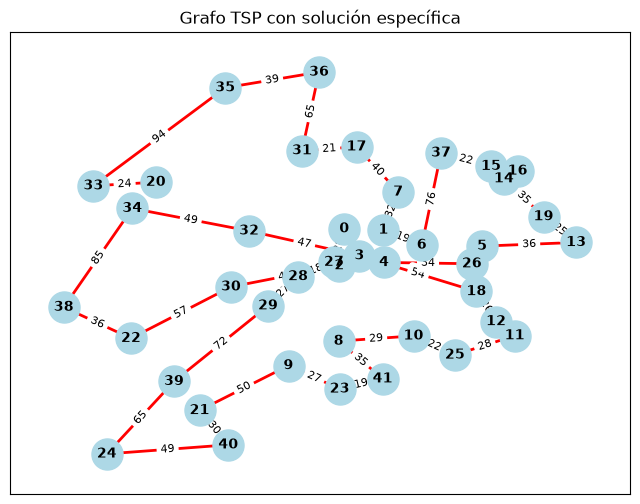

In [56]:
def recocido_simulado(problema, temperatura):
    # Generamos solución de referencia
    solucion_referencia = crear_solucion(nodos)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = []
    mejor_distancia = float("inf")

    iteraciones = 0

    # Mientras la temperatura no sea 0 (aquí no hay parada por iteraciones)
    while temperatura > .0001:
        iteraciones += 1

        # Genera una solución vecina
        vecina = genera_vecina_aleatorio(solucion_referencia)

        # Calculamos distancia
        distancia_vecina = distancia_total(vecina, problema)

        # Si es la mejor solución de todas se guarda siempre
        if (distancia_vecina < mejor_distancia):
            mejor_solucion = vecina
            mejor_distancia = distancia_vecina

        # Si la nueva vecina es o
        # Si el vecino es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
        if ((distancia_vecina < distancia_referencia) or probabilidad(temperatura, abs(distancia_referencia - distancia_vecina))):
            #solucion_referencia = copy.deepcopy(vecina)
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        # Bajamos la temperatura
        temperatura = bajar_temperatura(temperatura)

    return mejor_solucion, mejor_distancia, iteraciones

temperatura = 100000
mejor_solucion, mejor_distancia, iteraciones  = recocido_simulado(problema, temperatura)

print(f"La mejor solución encontrada es: {mejor_solucion} en {iteraciones} iteraciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

# Actividades Extra

## A) Mejora de algoritmo de búsqueda local

### 1) Búsqueda local con multiarranque

La búsqueda local puede quedar atrapada en un mínimo local que depende de la solución inicial. El **multiarranque** ejecuta varias veces la búsqueda local desde soluciones iniciales aleatorias distintas y conserva la mejor solución obtenida entre todas las ejecuciones.

In [ ]:
###############################################################################
# BÚSQUEDA LOCAL DESDE UNA SOLUCIÓN INICIAL
###############################################################################

def busqueda_local_desde_solucion(solucion_inicial, problema):
    """
    Ejecuta la búsqueda local ya utilizada en el notebook, pero comenzando
    desde una solución inicial recibida como parámetro.

    Retorna:
        mejor_solucion: mejor recorrido encontrado.
        mejor_distancia: distancia total del recorrido.
        iteraciones: número de iteraciones realizadas.
    """
    solucion_referencia = solucion_inicial.copy()
    mejor_solucion = solucion_referencia.copy()
    mejor_distancia = distancia_total(mejor_solucion, problema)
    iteraciones = 0

    while True:
        iteraciones += 1

        # Se utiliza la función de vecindad definida anteriormente.
        vecina = genera_mejor_vecina(solucion_referencia)
        distancia_vecina = distancia_total(vecina, problema)

        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina.copy()
            mejor_distancia = distancia_vecina
            solucion_referencia = vecina
        else:
            # No existe mejora en este entorno: se alcanzó un mínimo local.
            break

    return mejor_solucion, mejor_distancia, iteraciones


###############################################################################
# MULTIARRANQUE
###############################################################################

def busqueda_local_multiarranque(problema, numero_arranques):
    """
    Ejecuta la búsqueda local desde varias soluciones iniciales aleatorias
    y conserva el mejor resultado global.

    Retorna:
        mejor_solucion_global: mejor recorrido de todos los arranques.
        mejor_distancia_global: distancia de dicho recorrido.
        resultados: información de cada arranque.
    """
    if numero_arranques <= 0:
        raise ValueError("El número de arranques debe ser mayor que cero.")

    nodos_problema = list(problema.get_nodes())
    mejor_solucion_global = None
    mejor_distancia_global = float("inf")
    resultados = []

    for arranque in range(1, numero_arranques + 1):
        solucion_inicial = crear_solucion(nodos_problema)
        distancia_inicial = distancia_total(solucion_inicial, problema)

        solucion_local, distancia_local, iteraciones = \
            busqueda_local_desde_solucion(solucion_inicial, problema)

        resultados.append({
            "arranque": arranque,
            "distancia_inicial": distancia_inicial,
            "distancia_final": distancia_local,
            "iteraciones": iteraciones
        })

        if distancia_local < mejor_distancia_global:
            mejor_solucion_global = solucion_local.copy()
            mejor_distancia_global = distancia_local

    return mejor_solucion_global, mejor_distancia_global, resultados


Arranque  1: distancia inicial = 5335, distancia final = 1955, iteraciones = 37
Arranque  2: distancia inicial = 4114, distancia final = 1921, iteraciones = 33
Arranque  3: distancia inicial = 4965, distancia final = 1706, iteraciones = 39
Arranque  4: distancia inicial = 4751, distancia final = 1678, iteraciones = 36
Arranque  5: distancia inicial = 5077, distancia final = 1864, iteraciones = 29
Arranque  6: distancia inicial = 4915, distancia final = 1744, iteraciones = 46
Arranque  7: distancia inicial = 4987, distancia final = 1573, iteraciones = 40
Arranque  8: distancia inicial = 4601, distancia final = 1748, iteraciones = 37
Arranque  9: distancia inicial = 4925, distancia final = 1935, iteraciones = 41
Arranque 10: distancia inicial = 5302, distancia final = 1788, iteraciones = 32

Mejor solución obtenida mediante multiarranque:
[0, 32, 20, 33, 34, 38, 22, 39, 24, 40, 21, 9, 30, 31, 35, 36, 17, 7, 37, 15, 16, 14, 19, 13, 18, 10, 8, 23, 41, 25, 11, 12, 29, 28, 27, 2, 6, 5, 26, 4

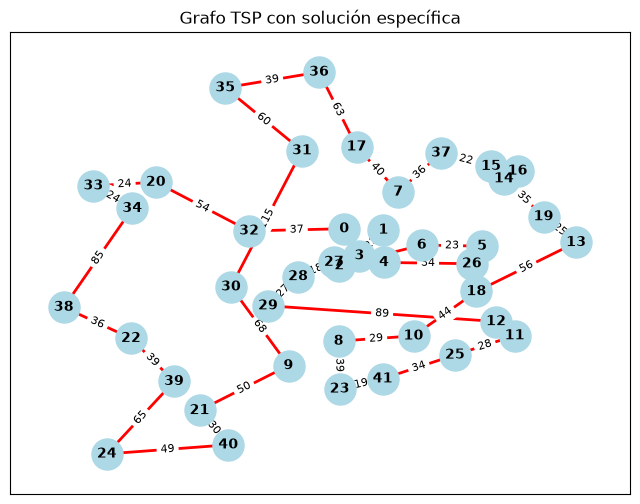

In [41]:
# Ejemplo de ejecución del multiarranque
numero_arranques = 10

mejor_solucion_ma, mejor_distancia_ma, resultados_ma = \
    busqueda_local_multiarranque(problema, numero_arranques)

for resultado in resultados_ma:
    print(
        f"Arranque {resultado['arranque']:2d}: "
        f"distancia inicial = {resultado['distancia_inicial']:4d}, "
        f"distancia final = {resultado['distancia_final']:4d}, "
        f"iteraciones = {resultado['iteraciones']}"
    )

print("\nMejor solución obtenida mediante multiarranque:")
print(mejor_solucion_ma)
print(f"Mejor distancia: {mejor_distancia_ma}")

plot_tsp_solution(problema.edge_weights, mejor_solucion_ma)

La estrategia de multiarranque consistió en ejecutar la búsqueda local diez veces, utilizando en cada ejecución una solución inicial generada aleatoriamente. Como resultado, se obtuvieron soluciones finales con distintas calidades, cuyas distancias oscilaron entre 1573 y 1955. La mejor solución encontrada presentó una distancia de 1573, mejorando significativamente todas las soluciones iniciales, que se encontraban entre 4114 y 5335. Estos resultados evidencian que el desempeño de la búsqueda local depende de la solución desde la cual comienza el proceso, ya que diferentes puntos de partida pueden conducir a distintos óptimos locales. En consecuencia, la estrategia de multiarranque incrementa la probabilidad de encontrar soluciones de mejor calidad al explorar diversas regiones del espacio de búsqueda y seleccionar finalmente la mejor de ellas.

### 2) Búsqueda en entornos variables

La búsqueda en entornos variables evita depender de un único operador de vecindad. En este caso se emplean tres entornos:

1. **Intercambio:** intercambia las posiciones de dos nodos.
2. **Inversión:** invierte el segmento comprendido entre dos posiciones.
3. **Inserción:** extrae un nodo y lo inserta en otra posición.

Cuando un entorno encuentra una mejora, la búsqueda vuelve al primer entorno. Cuando ninguno de los tres entornos mejora la solución actual, el algoritmo termina.

In [ ]:
###############################################################################
# OPERADORES PARA LOS DISTINTOS ENTORNOS
###############################################################################

def mejor_vecina_intercambio(solucion, problema):
    """Obtiene la mejor vecina intercambiando dos nodos, sin mover el nodo 0."""
    mejor_vecina = solucion.copy()
    mejor_distancia = distancia_total(solucion, problema)

    for i in range(1, len(solucion) - 1):
        for j in range(i + 1, len(solucion)):
            vecina = solucion.copy()
            vecina[i], vecina[j] = vecina[j], vecina[i]
            distancia_vecina = distancia_total(vecina, problema)

            if distancia_vecina < mejor_distancia:
                mejor_vecina = vecina
                mejor_distancia = distancia_vecina

    return mejor_vecina, mejor_distancia


def mejor_vecina_inversion(solucion, problema):
    """Obtiene la mejor vecina invirtiendo un segmento del recorrido."""
    mejor_vecina = solucion.copy()
    mejor_distancia = distancia_total(solucion, problema)

    for i in range(1, len(solucion) - 1):
        for j in range(i + 1, len(solucion)):
            vecina = solucion[:i] + solucion[i:j + 1][::-1] + solucion[j + 1:]
            distancia_vecina = distancia_total(vecina, problema)

            if distancia_vecina < mejor_distancia:
                mejor_vecina = vecina
                mejor_distancia = distancia_vecina

    return mejor_vecina, mejor_distancia


def mejor_vecina_insercion(solucion, problema):
    """Obtiene la mejor vecina trasladando un nodo a otra posición."""
    mejor_vecina = solucion.copy()
    mejor_distancia = distancia_total(solucion, problema)

    for i in range(1, len(solucion)):
        for j in range(1, len(solucion)):
            if i == j:
                continue

            vecina = solucion.copy()
            nodo = vecina.pop(i)
            vecina.insert(j, nodo)
            distancia_vecina = distancia_total(vecina, problema)

            if distancia_vecina < mejor_distancia:
                mejor_vecina = vecina
                mejor_distancia = distancia_vecina

    return mejor_vecina, mejor_distancia

In [44]:
###############################################################################
# BÚSQUEDA EN ENTORNOS VARIABLES
###############################################################################

def busqueda_entornos_variables(problema, solucion_inicial=None):
    """
    Aplica una búsqueda descendente en entornos variables.

    Si un entorno mejora la solución, se vuelve al primer entorno.
    Si no mejora, se prueba el entorno siguiente.

    Retorna:
        mejor_solucion: mejor recorrido encontrado.
        mejor_distancia: distancia total del recorrido.
        iteraciones: cantidad de entornos evaluados.
        historial: mejoras producidas durante la búsqueda.
    """
    nodos_problema = list(problema.get_nodes())

    if solucion_inicial is None:
        solucion_actual = crear_solucion(nodos_problema)
    else:
        solucion_actual = solucion_inicial.copy()

    distancia_actual = distancia_total(solucion_actual, problema)

    entornos = [
        ("intercambio", mejor_vecina_intercambio),
        ("inversión", mejor_vecina_inversion),
        ("inserción", mejor_vecina_insercion)
    ]

    k = 0
    iteraciones = 0
    historial = []

    while k < len(entornos):
        iteraciones += 1
        nombre_entorno, funcion_entorno = entornos[k]

        vecina, distancia_vecina = funcion_entorno(solucion_actual, problema)

        if distancia_vecina < distancia_actual:
            solucion_actual = vecina.copy()
            distancia_actual = distancia_vecina
            historial.append({
                "iteracion": iteraciones,
                "entorno": nombre_entorno,
                "distancia": distancia_actual
            })

            # Al mejorar, se vuelve a explorar desde el primer entorno.
            k = 0
        else:
            # Si no mejora, se cambia al entorno siguiente.
            k += 1

    return solucion_actual, distancia_actual, iteraciones, historial

Distancia inicial: 4352
Distancia final: 1273
Entornos evaluados: 61
Cantidad de mejoras: 48

Mejoras encontradas:
Iteración  1 - entorno: intercambio - distancia: 3848
Iteración  2 - entorno: intercambio - distancia: 3487
Iteración  3 - entorno: intercambio - distancia: 3189
Iteración  4 - entorno: intercambio - distancia: 2948
Iteración  5 - entorno: intercambio - distancia: 2718
Iteración  6 - entorno: intercambio - distancia: 2558
Iteración  7 - entorno: intercambio - distancia: 2407
Iteración  8 - entorno: intercambio - distancia: 2273
Iteración  9 - entorno: intercambio - distancia: 2204
Iteración 10 - entorno: intercambio - distancia: 2141
Iteración 11 - entorno: intercambio - distancia: 2099
Iteración 12 - entorno: intercambio - distancia: 2062
Iteración 13 - entorno: intercambio - distancia: 2015
Iteración 14 - entorno: intercambio - distancia: 1987
Iteración 15 - entorno: intercambio - distancia: 1961
Iteración 16 - entorno: intercambio - distancia: 1938
Iteración 17 - entorn

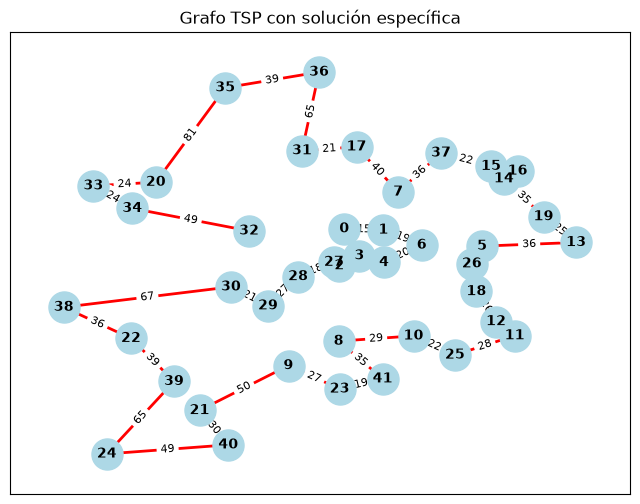

In [45]:
# Ejemplo de ejecución de la búsqueda en entornos variables
solucion_inicial_bev = crear_solucion(nodos)
distancia_inicial_bev = distancia_total(solucion_inicial_bev, problema)

mejor_solucion_bev, mejor_distancia_bev, iteraciones_bev, historial_bev = \
    busqueda_entornos_variables(problema, solucion_inicial_bev)

print(f"Distancia inicial: {distancia_inicial_bev}")
print(f"Distancia final: {mejor_distancia_bev}")
print(f"Entornos evaluados: {iteraciones_bev}")
print(f"Cantidad de mejoras: {len(historial_bev)}")

print("\nMejoras encontradas:")
for mejora in historial_bev:
    print(
        f"Iteración {mejora['iteracion']:2d} - "
        f"entorno: {mejora['entorno']:11s} - "
        f"distancia: {mejora['distancia']}"
    )

print("\nMejor solución obtenida mediante entornos variables:")
print(mejor_solucion_bev)

plot_tsp_solution(problema.edge_weights, mejor_solucion_bev)

La búsqueda en entornos variables obtuvo una reducción significativa de la distancia total de la ruta, pasando de una solución inicial con distancia 4352 a una solución final con distancia 1273. Esto representa una mejora aproximada del 70,7 %. Durante el proceso se evaluaron 61 entornos y se encontraron 48 movimientos de mejora. Inicialmente, la mayor parte de las reducciones se consiguió mediante el entorno de intercambio de nodos. Posteriormente, al no encontrarse nuevas mejoras con dicho entorno, el algoritmo utilizó otros tipos de movimientos, como la inserción, alcanzando una solución de mejor calidad. Este comportamiento evidencia la ventaja de la búsqueda en entornos variables frente a una búsqueda local convencional, ya que permite cambiar la estructura de vecindad y disminuir la posibilidad de quedar detenido prematuramente en un óptimo local.

### Interpretación de los resultados

El **multiarranque** mejora la búsqueda local porque explora varias regiones del espacio de soluciones. Cada ejecución puede terminar en un mínimo local distinto y, al conservar el mejor resultado, disminuye la dependencia de una única solución inicial aleatoria.

La **búsqueda en entornos variables** amplía la exploración al utilizar diferentes operadores de vecindad. Una solución que no puede mejorar mediante intercambio todavía puede mejorar mediante inversión o inserción. Por ello, esta estrategia tiene mayores posibilidades de escapar de mínimos locales asociados a un único entorno.

## B) Recocido Simulado

### Mejora en la selección de vecinos

En la versión original se genera un único vecino aleatorio mediante el intercambio de dos nodos. En esta mejora se generan varios candidatos utilizando tres operadores de vecindad: **intercambio**, **inversión** e **inserción**. Posteriormente se selecciona el candidato con menor distancia y se aplica la misma regla de aceptación del recocido simulado. De este modo se mejora la calidad del vecino evaluado sin modificar las funciones dadas inicialmente en la actividad.


In [57]:
###############################################################################
# MEJORA EN LA SELECCIÓN DE VECINOS PARA RECOCIDO SIMULADO
###############################################################################

# Genera un vecino intercambiando dos nodos.
# Se mantiene fijo el nodo inicial ubicado en la posición 0.
def vecino_intercambio_rs(solucion):
    vecina = solucion.copy()
    i, j = random.sample(range(1, len(vecina)), 2)
    vecina[i], vecina[j] = vecina[j], vecina[i]
    return vecina


# Genera un vecino invirtiendo el segmento comprendido entre dos posiciones.
def vecino_inversion_rs(solucion):
    i, j = sorted(random.sample(range(1, len(solucion)), 2))
    return solucion[:i] + solucion[i:j + 1][::-1] + solucion[j + 1:]


# Genera un vecino extrayendo un nodo e insertándolo en otra posición.
def vecino_insercion_rs(solucion):
    vecina = solucion.copy()
    i, j = random.sample(range(1, len(vecina)), 2)
    nodo = vecina.pop(i)
    vecina.insert(j, nodo)
    return vecina


def seleccionar_vecino_mejorado(solucion, problema, cantidad_candidatos=6):
    """
    Genera varios vecinos con diferentes operadores y devuelve el candidato
    con menor distancia. También informa qué operador produjo dicho vecino.
    """
    if cantidad_candidatos < 1:
        raise ValueError("cantidad_candidatos debe ser mayor o igual que 1")

    operadores = {
        "intercambio": vecino_intercambio_rs,
        "inversión": vecino_inversion_rs,
        "inserción": vecino_insercion_rs
    }

    mejor_vecina = None
    mejor_distancia_vecina = float("inf")
    mejor_operador = None

    nombres_operadores = list(operadores.keys())

    for candidato in range(cantidad_candidatos):
        # Los tres primeros candidatos garantizan que se pruebe cada operador.
        # Los restantes operadores se seleccionan aleatoriamente.
        if candidato < len(nombres_operadores):
            nombre = nombres_operadores[candidato]
        else:
            nombre = random.choice(nombres_operadores)

        vecina = operadores[nombre](solucion)
        distancia_vecina = distancia_total(vecina, problema)

        if distancia_vecina < mejor_distancia_vecina:
            mejor_vecina = vecina
            mejor_distancia_vecina = distancia_vecina
            mejor_operador = nombre

    return mejor_vecina, mejor_distancia_vecina, mejor_operador

Recocido simulado con selección mejorada de vecinos
Distancia inicial: 4787
Mejor distancia: 1273
Iteraciones: 207223
Soluciones aceptadas: 79599
Soluciones peores aceptadas: 38259
Operadores seleccionados: {'intercambio': 45826, 'inversión': 87904, 'inserción': 73493}
Mejor solución: [0, 1, 6, 4, 3, 27, 2, 28, 29, 30, 38, 22, 39, 24, 40, 21, 9, 23, 41, 8, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 16, 15, 37, 7, 17, 31, 36, 35, 20, 33, 34, 32]


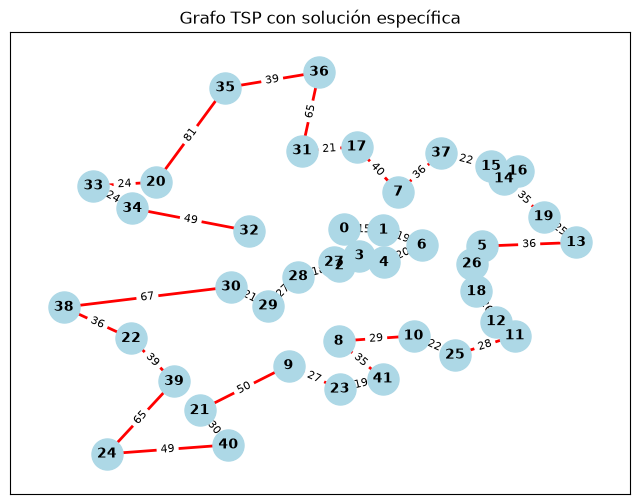

In [58]:
def recocido_simulado_vecinos_mejorados(
        problema, temperatura, cantidad_candidatos=6, temperatura_minima=0.0001):
    """
    Recocido simulado que mejora la selección del vecino generando varios
    candidatos en cada iteración. No reemplaza la versión original.
    """
    nodos_problema = list(problema.get_nodes())

    # Solución inicial y mejor solución conocida.
    solucion_referencia = crear_solucion(nodos_problema)
    distancia_referencia = distancia_total(solucion_referencia, problema)

    mejor_solucion = solucion_referencia.copy()
    mejor_distancia = distancia_referencia
    distancia_inicial = distancia_referencia

    iteraciones = 0
    soluciones_aceptadas = 0
    peores_aceptadas = 0
    uso_operadores = {"intercambio": 0, "inversión": 0, "inserción": 0}

    while temperatura > temperatura_minima:
        iteraciones += 1

        # Se generan varios vecinos y se selecciona el mejor candidato.
        vecina, distancia_vecina, operador = seleccionar_vecino_mejorado(
            solucion_referencia, problema, cantidad_candidatos
        )
        uso_operadores[operador] += 1

        # Se actualiza la mejor solución global.
        if distancia_vecina < mejor_distancia:
            mejor_solucion = vecina.copy()
            mejor_distancia = distancia_vecina

        delta = distancia_vecina - distancia_referencia

        # Se aceptan siempre las mejoras. Las soluciones peores pueden
        # aceptarse según la temperatura y la diferencia de distancia.
        if delta < 0 or probabilidad(temperatura, delta):
            if delta > 0:
                peores_aceptadas += 1

            solucion_referencia = vecina
            distancia_referencia = distancia_vecina
            soluciones_aceptadas += 1

        temperatura = bajar_temperatura(temperatura)

    estadisticas = {
        "distancia_inicial": distancia_inicial,
        "distancia_final": mejor_distancia,
        "iteraciones": iteraciones,
        "soluciones_aceptadas": soluciones_aceptadas,
        "soluciones_peores_aceptadas": peores_aceptadas,
        "uso_operadores": uso_operadores
    }

    return mejor_solucion, mejor_distancia, iteraciones, estadisticas


# Ejecución de la versión mejorada
temperatura_inicial = 100000
cantidad_candidatos = 6

mejor_solucion_rs, mejor_distancia_rs, iteraciones_rs, estadisticas_rs = (
    recocido_simulado_vecinos_mejorados(
        problema,
        temperatura_inicial,
        cantidad_candidatos=cantidad_candidatos
    )
)

print("Recocido simulado con selección mejorada de vecinos")
print(f"Distancia inicial: {estadisticas_rs['distancia_inicial']}")
print(f"Mejor distancia: {mejor_distancia_rs}")
print(f"Iteraciones: {iteraciones_rs}")
print(f"Soluciones aceptadas: {estadisticas_rs['soluciones_aceptadas']}")
print(f"Soluciones peores aceptadas: {estadisticas_rs['soluciones_peores_aceptadas']}")
print(f"Operadores seleccionados: {estadisticas_rs['uso_operadores']}")
print(f"Mejor solución: {mejor_solucion_rs}")

plot_tsp_solution(problema.edge_weights, mejor_solucion_rs)

**Interpretación**

La selección mejorada explora más de una alternativa antes de decidir qué vecino evaluar. Los operadores de intercambio, inversión e inserción producen modificaciones diferentes sobre la ruta, aumentando la diversidad de soluciones candidatas. Aunque se escoge el mejor vecino del conjunto generado, el algoritmo conserva el criterio probabilístico del recocido simulado, por lo que todavía puede aceptar temporalmente soluciones peores para escapar de óptimos locales. El parámetro `cantidad_candidatos` controla el equilibrio entre calidad y costo computacional: un valor mayor permite revisar más vecinos por iteración, pero requiere más cálculos de distancia.

**Conclusión**

El recocido simulado con selección mejorada de vecinos obtuvo una reducción significativa en la distancia total de la ruta, pasando de una solución inicial con distancia 4787 a una mejor solución con distancia 1273, lo que representa una mejora aproximada del 73,4 %. Durante las 207.223 iteraciones se aceptaron 79.599 soluciones, de las cuales 38.259 correspondieron a soluciones temporalmente peores. Esta aceptación controlada permitió que el algoritmo escapara de posibles óptimos locales y explorara distintas regiones del espacio de búsqueda. En cuanto a los operadores utilizados para generar vecinos, la inversión fue seleccionada con mayor frecuencia, seguida por la inserción y el intercambio. Esto evidencia que la generación de múltiples candidatos mediante distintos operadores de vecindad mejora la exploración y permite obtener soluciones de alta calidad.

## Referencias

+ Camacho, José M. (2026a). AG3 – Actividad Guiada 3. 03MIAR – Algoritmos de optimización [Archivo PDF]. Campus Virtual VIU. universidadviu.com

+ Camacho, José M. (2026b). VC6 – Algoritmos genéticos. 03MIAR – Algoritmos de optimización [Archivo PDF]. Universidad Internacional de Valencia.

+ Camacho, José M. (2026c). VC5 – Algoritmos Heurísticos. 03MIAR – Algoritmos de optimización [Archivo PDF]. Universidad Internacional de Valencia.

+ Camacho, José M. (2026d). AG3 – Actividad Guiada 3 (2ª parte). 03MIAR – Algoritmos de optimización [Archivo PDF]. Universidad Internacional de Valencia.

### Declaración de uso de IA

Se ha utilizado herramienta de IA generativa para formatear la citación a formato APA, revisar bibliografía, revisar algunas ortografías, formatear formulas en Markdown, y como herramienta consultiva para revisar instrucciones y/o errores del uso de sintaxis para Python.